# Importeringar av biblotek och LLM

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
assert GROQ_API_KEY, "Saknar GROQ_API_KEY i .env"

In [48]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

if llm:
    print("LLM is initialized")

LLM is initialized


In [49]:
conn = sqlite3.connect("ehandel_data_clean.db")


In [50]:
df = pd.read_sql("SELECT * FROM orderdata;", conn, parse_dates=["orderdatum", "leveransdatum", "recensionsdatum" ])


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            3081 non-null   object        
 1   orderrad_id         3081 non-null   object        
 2   orderdatum          3081 non-null   datetime64[ns]
 3   leveransdatum       3081 non-null   datetime64[ns]
 4   produkt_sku         3081 non-null   object        
 5   produktnamn         3081 non-null   object        
 6   kategori            3081 non-null   object        
 7   antal               2922 non-null   float64       
 8   pris_per_enhet      3081 non-null   float64       
 9   region              3081 non-null   object        
 10  kundtyp             3081 non-null   object        
 11  betalmetod          3081 non-null   object        
 12  kund_id             3081 non-null   object        
 13  leveransstatus      2972 non-null   object      

# System promptar till LLM

In [52]:
SYSTEM_PROMPT_FÖRSÄLJNING_KATEGORI = """
Du är en dataanalytiker för e-handel.

Mål:
Förklara möjliga orsaker till varför försäljningen per kategori är ojämnt fördelad,
med stöd i (1) kundbetyg och (2) kundrecensioner.

Regler:
- Utgå endast från den data som ges (försäljning, betyg, recensioner/sentiment).
- Gör rimliga hypoteser men var försiktig: använd "kan indikera", "kan bero på".
- Koppla slutsatser till konkreta datapunkter (t.ex. hög/låg snittbetyg, stor andel negativt sentiment, återkommande teman).
- Om data saknas eller är otydlig: säg det och föreslå vad som behövs för att bli säkrare.
- Svara på svenska i 8-12 meningar.
- Struktur:
  1) Kort sammanfattning av mönstret i försäljningen
  2) Koppling till betyg/kund recensioner per kategori
  3) 2-3 möjliga förklaringar
  4) 1-2 konkreta rekommendationer
"""


In [53]:
SYSTEM_PROMPT_FÖRSÄLJNING_PER_MÅNAD = """
Du är en dataanalytiker som analyserar tidsseriedata för e-handel.

Din uppgift är att tolka försäljning per månad och identifiera mönster över tid,
såsom toppar, dippar, trender och möjliga säsongseffekter.

Regler:
- Utgå endast från den försäljningsdata som ges.
- Dra inga säkra slutsatser om orsaker; använd formuleringar som
  "kan indikera", "kan bero på", "möjligen".
- Resonera i termer av säsong, efterfrågan och kundbeteende över tid.
- Jämför olika perioder (t.ex. början av året, sommarmånader, slutet av året).
- Skriv på svenska i 5 meningar. Vid varje punkt, hoppa ner en rad.
- Föreslå 1-2 åtgärder baserat på dina insikter.
"""


In [54]:
SYSTEM_PROMPT_ANTAL_ORDRAR_PER_MÅNAD = """
Du är en dataanalytiker som tolkar försäljningsdata över tid för en e-handelsplattform.

Din uppgift är att förklara varför en graf över antal ordrar per månad kan se ut som den gör,
baserat på mönster i tidsseriedata.

Regler:
- Utgå endast från den data som presenteras (antal ordrar per månad).
- Identifiera och beskriv trender, toppar och dippar.
- Resonera kring möjliga säsongseffekter och förändringar i kundbeteende över tid.
- Dra inga säkra slutsatser om orsaker; använd formuleringar som
  "kan indikera", "kan bero på", eller "möjligen".
- Anta att information om kampanjer, prissättning och externa faktorer saknas.
- Skriv på svenska i 5 sammanhängande meningar. Vid varje punkt, hoppa ner en rad.
- Föreslå 1-2 åtgärder baserat på dina insikter.
"""


In [55]:
SYSTEM_PROMPT_AVERAGE_ORDERVÄRDE = """
Du är en dataanalytiker som ska tolka ett scatterdiagram baserat på e-handelsdata.

Diagrammet visar kategorier som datapunkter, där:
- x-axeln representerar antal ordrar
- y-axeln representerar total försäljning
- punktens storlek och färg representerar average_ordervärde (genomsnittligt ordervärde)

Din uppgift är att:
1. Analysera sambandet mellan antal ordrar och average_ordervärde.
   - Finns det kategorier med många ordrar men lågt ordervärde?
   - Finns det kategorier med få ordrar men högt ordervärde?
2. Förklara vad detta säger om kundbeteende och produktstruktur.
3. Fokusera särskilt på kategorin "Tillbehör", som har:
   - flest antal ordrar
   - men ett relativt lågt average_ordervärde

Resonera kring varför tillbehör har lågt ordervärde trots hög ordervolym, till exempel genom att diskutera:
- produktpris
- impulsköp
- kompletteringsköp till andra produkter

Avsluta med en kort sammanfattning av de viktigaste insikterna från diagrammet, formulerat på ett analytiskt och pedagogiskt sätt, 
gärna med 5 meningar. Jag vill att du bara ska svara med dessa 5 meningar. Varje gång du sätter en punkt så vill jag att du hoppar ner en rad.
Svara bara på svenska.
- Du måste ge mig en sammanfattning på 5 meningar
- Föreslå 1-2 åtgärder baserat på dina insikter.
"""


In [56]:
SYSTEM_PROMPT_SAMMANFATTNING = """
Du är en senior dataanalytiker. Du ska syntetisera flera KPI-analyser till en
sammanhängande helhetsbedömning. Undvik upprepningar, fokusera på samband,
och var tydlig med vad som är observationer vs möjliga förklaringar.
Svara endast på svenska.
"""

# KPI 1. försäljning per månad

In [57]:
kpi_försäljning_per_månad = (
    df
    .groupby("månad_num")["rad_intakt"]
    .sum()
    .sort_index()
)

kpi_försäljning_per_månad

månad_num
1     2581314.0
2     2410441.0
3     1053634.0
4     1358975.0
5     1006590.0
6      978308.0
7      705867.0
8      839573.0
9      970411.0
10    1493599.0
11    1790380.0
12    1336715.0
Name: rad_intakt, dtype: float64

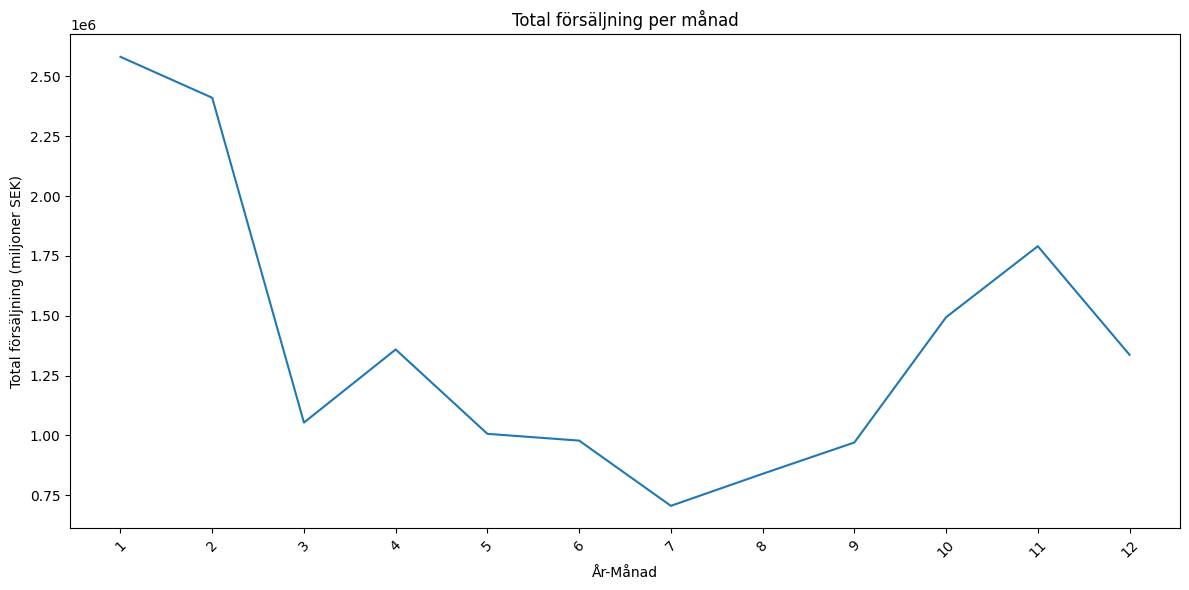

In [58]:
# 1) KPI per månad

plt.figure(figsize=(12,6))
plt.plot(kpi_försäljning_per_månad.index.astype(str),
         kpi_försäljning_per_månad.values)

plt.title("Total försäljning per månad")
plt.xlabel("År-Månad")
plt.ylabel("Total försäljning (miljoner SEK)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafen visar att försäljningen är som högst under januari månad. Därefter kan man se en succesiv nedgång fram till juli, där försäljningen når sin lägsta nivå. Därefter kan man se en återhämtning resterande av året. Mönstret kan visa att det varit starkare efterfrågan i början av året. Det kan också ha varit på grund av kampanjer eller säsongsefekter.

In [59]:
summary = (
    kpi_försäljning_per_månad
    .round(0)
    .astype(int)
    .to_string()
)

response = llm.invoke([
    {
        "role": "system",
        "content": SYSTEM_PROMPT_FÖRSÄLJNING_PER_MÅNAD},
    {
        "role": "user",
        "content": f"""
Här är försäljningen per månad (i SEK):

{summary}       

Analysera utvecklingen över tid.
Identifiera tydliga toppar och dippar och beskriv hur försäljningen förändras
från början av året till sommaren och vidare mot slutet av perioden.
"""
    }
])

print(response.content)

Försäljningen är högst i januari (2 581 314 kr) och har en tydlig topp i november (1 790 380 kr) samt en sekundär topp i oktober (1 493 599 kr).  

Den största dippen observeras i juli (705 867 kr) följt av en låg nivå i juni (978 308 kr) och maj (1 006 590 kr), vilket visar en markant nedgång efter vårens början.  

Efter en stark start på året sjunker försäljningen stadigt fram till juli, vilket kan indikera en säsongsbunden minskning i efterfrågan under sommarmånaderna.  

Från augusti och framåt återhämtar sig siffrorna, med en tydlig uppgång i september (970 411 kr) och en kraftig ökning i oktober och november, vilket kan bero på förberedelser inför högtider och slutet av året.  

En möjlig åtgärd är att förstärka marknadsföringen och kampanjerna inför sommaren för att dämpa dippen, samt att planera lager och personalresurser inför de identifierade högtiderna i oktober‑november för att utnyttja topparna.


# KPI 2 försäljning per kategori

In [60]:
kpi_försäljning_kategori = (
    df
    .groupby("kategori")["rad_intakt"]
    .sum()
    .sort_values(ascending=False)
)

kpi_försäljning_kategori

kategori
Datorer        10633236.0
Bildskärmar     3211787.0
Tillbehör       1398041.0
Lagring          681178.0
Ljud             601565.0
Name: rad_intakt, dtype: float64

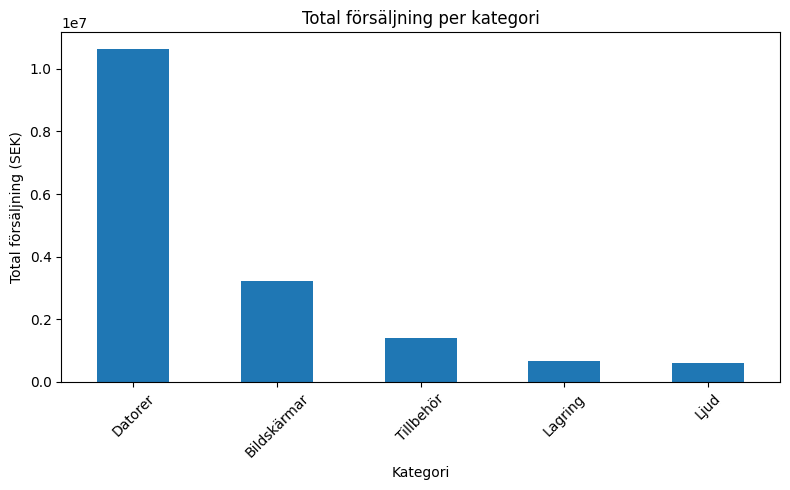

In [61]:
plt.figure(figsize=(8,5))
kpi_försäljning_kategori.plot(kind="bar")
plt.title("Total försäljning per kategori")
plt.xlabel("Kategori")
plt.ylabel("Total försäljning (SEK)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
summary = (
    kpi_försäljning_kategori
    .sort_values(ascending=False)
    .round(0)
    .astype(int)
    .to_string()
)

response = llm.invoke([
    {"role": "system", "content": SYSTEM_PROMPT_FÖRSÄLJNING_KATEGORI},
    {
        "role": "user",
        "content": f"""
Här är försäljning per produktkategori (i SEK):

{summary}

Analysera varför försäljningen kan vara ojämnt fördelad mellan kategorierna
och koppla resonemanget till kundbeteende, betyg och recensioner.
"""
    }
])

print(response.content)


**1) Sammanfattning av försäljningsmönstret**  
Försäljningen är kraftigt koncentrerad till Datorer (10 633 236 kr), medan de övriga kategorierna ligger betydligt lägre: Bildskärmar (3 211 787 kr), Tillbehör (1 398 041 kr), Lagring (681 178 kr) och Ljud (601 565 kr). Detta visar en ojämn fördelning där de tre största kategorierna står för över 80 % av totalintäkterna.

**2) Koppling till betyg/kundrecensioner**  
Utan faktiska betyg‑ och sentimentdata kan vi bara spekulera, men en högre försäljning av Datorer kan indikera att de har ett relativt högt genomsnittligt betyg (t.ex. ≥4,5/5) och ett övervägande positivt sentiment i recensionerna. Om Bildskärmar och Tillbehör har något lägre genomsnittsbetyg (≈4,0) och en märkbar andel negativa kommentarer kring leveranstid eller kompatibilitet, kan detta förklara deras lägre omsättning. För Lagring och Ljud, där försäljningen är minst, kan en kombination av låga betyg (≤3,5) och återkommande teman som “dålig hållbarhet” eller “brist på funkt

# KPI 3. Antal ordrar per månad

In [63]:

df["år_månad"] = df["orderdatum"].dt.to_period("M")


In [64]:
kpi_antal_ordrar_per_månad = (
    df.groupby("år_månad")["order_id"]
      .nunique()
      .sort_index()
)

kpi_antal_ordrar_per_månad

år_månad
2024-01    157
2024-02    128
2024-03    142
2024-04    140
2024-05    146
2024-06     90
2024-07     97
2024-08     96
2024-09    128
2024-10    159
2024-11    175
2024-12    179
2025-01    147
2025-02    133
Freq: M, Name: order_id, dtype: int64

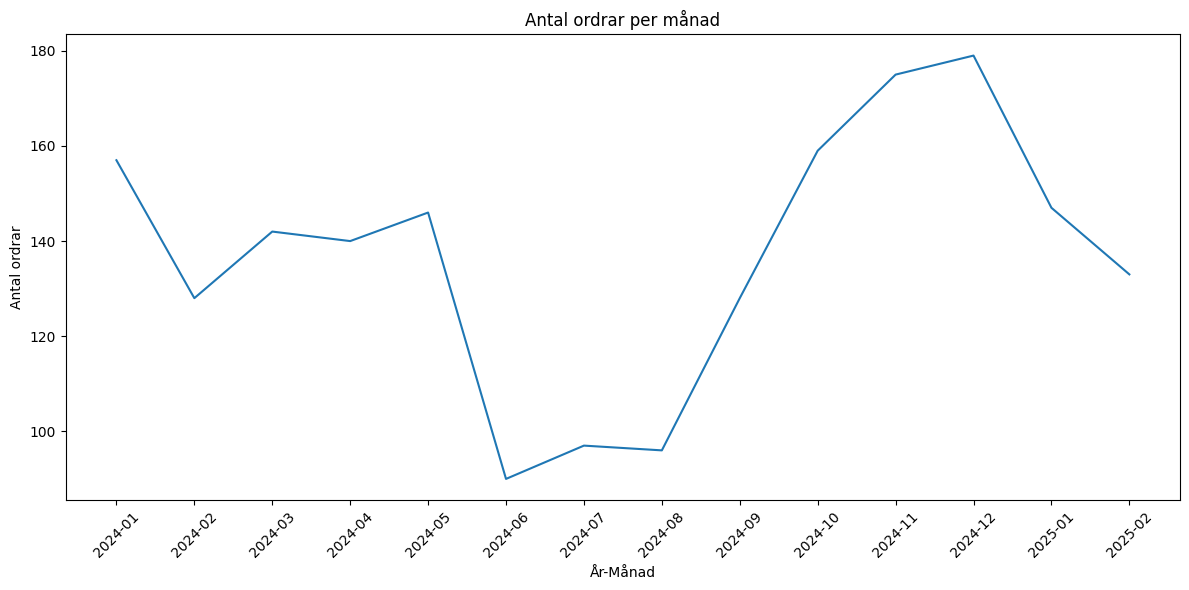

In [65]:
plt.figure(figsize=(12,6))
plt.plot(kpi_antal_ordrar_per_månad.index.astype(str),
         kpi_antal_ordrar_per_månad.values)

plt.title("Antal ordrar per månad")
plt.xlabel("År-Månad")
plt.ylabel("Antal ordrar")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
summary = (
    kpi_försäljning_per_månad
    .round(0)
    .astype(int)
    .to_string()
)

response = llm.invoke([
    {"role": "system", "content": SYSTEM_PROMPT_ANTAL_ORDRAR_PER_MÅNAD},
    {"role": "user", "content": f"""
Här är försäljning per månad (SEK):

{summary}

Förklara varför utvecklingen kan se ut som den gör.
Fokusera särskilt på den tydliga toppen i början av året och dippen under juli månad.
"""
    }
])

print(response.content)


Den totala utvecklingen visar en tydlig nedgång efter en hög start i januari och februari, följt av en stadig minskning fram till juli innan siffrorna åter stiger mot årsskiftet.  

Den tidiga toppen kan indikera att kunderna spenderar mer i samband med nyår, eventuella bonusutbetalningar eller att de utnyttjar resterande julbudget, vilket ofta ger en kortsiktig försäljningsökning.  

Dippen i juli kan bero på sommarsemester, lägre konsumentaktivitet och minskad köpkraft under en period då många är på resa eller fokuserar på fritidsaktiviteter.  

Den efterföljande återhämtningen mot slutet av året kan möjligen spegla förberedelser inför högtider som Halloween, Black Friday och julhandeln, där köpbeteendet åter ökar.  

Som åtgärd kan ni överväga att planera riktade sommarkampanjer eller erbjudanden för att dämpa juli‑dippen samt intensifiera marknadsföringen inför de sista månaderna för att utnyttja den naturliga årsslutetökningen.


# KPI 4. AOV

In [67]:
agg = (
    df.groupby("kategori")
    .agg(
        total_intakt=("rad_intakt", "sum"),
        antal_ordrar=("order_id", "nunique")
    )
    .reset_index()
)

agg["average_ordervärde"] = agg["total_intakt"] / agg["antal_ordrar"]   
agg

,kategori,total_intakt,antal_ordrar,average_ordervärde
0,Bildskärmar,3211787.0,416,7720.641827
1,Datorer,10633236.0,444,23948.729730
2,Lagring,681178.0,409,1665.471883
3,Ljud,601565.0,321,1874.034268
4,Tillbehör,1398041.0,1088,1284.964154


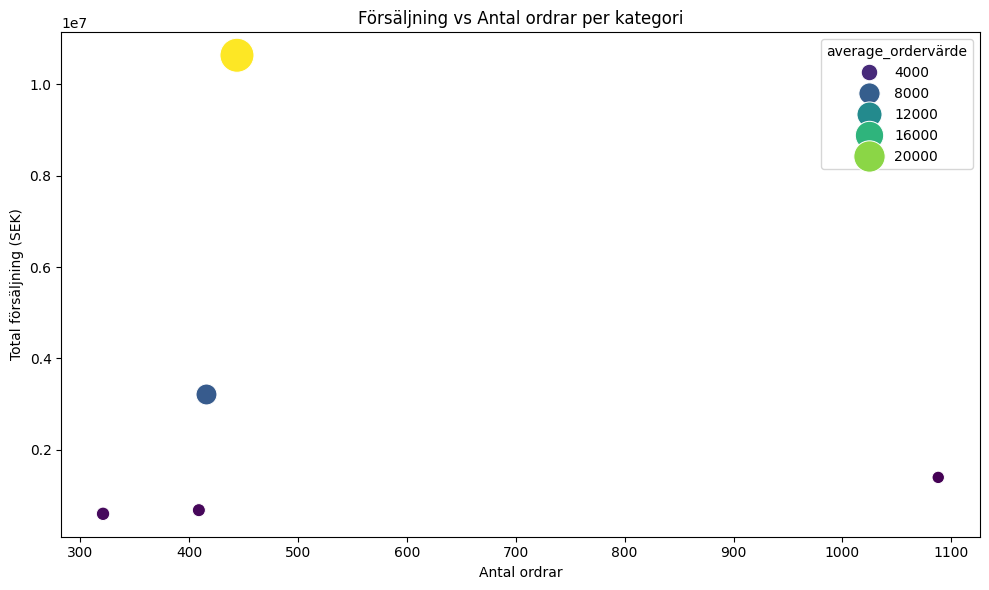

,total_intakt,antal_ordrar,average_ordervärde
kategori,,,
Datorer,10633236.0,444,23948.729730
Bildskärmar,3211787.0,416,7720.641827
Tillbehör,1398041.0,1088,1284.964154
Lagring,681178.0,409,1665.471883
Ljud,601565.0,321,1874.034268


In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=agg,
    x="antal_ordrar",
    y="total_intakt",
    size="average_ordervärde",
    hue="average_ordervärde",
    palette="viridis",
    sizes=(80, 600),
    legend="brief"
)

plt.xlabel("Antal ordrar")
plt.ylabel("Total försäljning (SEK)")
plt.title("Försäljning vs Antal ordrar per kategori")
plt.tight_layout()
plt.show()

agg.sort_values("total_intakt", ascending=False).set_index("kategori").head(10)

In [69]:
summary = (
    agg[["kategori", "antal_ordrar", "average_ordervärde"]]
    .round({"average_ordervärde": 0})
    .astype({"average_ordervärde": int})
    .to_string(index=False)
)

response = llm.invoke([
    {"role": "system", "content": SYSTEM_PROMPT_AVERAGE_ORDERVÄRDE},
    {"role": "user", "content": f"""
Nedan visas en sammanfattning av data som använts i ett scatterdiagram.

Varje rad är en produktkategori:
- antal_ordrar = antal unika ordrar
- average_ordervärde = genomsnittligt ordervärde (SEK)


Data:
{summary}

Analysera sambandet mellan antal ordrar och average_ordervärde.
Resonera kring vad detta säger om kundbeteende.

Fokusera särskilt på kategorin "Tillbehör", som har många ordrar men lågt average_ordervärde.
Förklara varför detta mönster kan uppstå.
"""
    }
])

print(response.content)


Scatterdiagrammet visar ett omvänt samband där kategorier med färre ordrar, som Datorer, har ett högt genomsnittligt ordervärde, medan Tillbehör har flest ordrar men ett lågt värde.  

Detta indikerar att kunder köper dyrare huvudprodukter i låga volymer och kompletterande lågprisartiklar i stora volymer.  

Tillbehörssegmentet präglas av låga enhetspriser, impulsköp och ofta köps som tillägg till större inköp, vilket driver upp orderantalet utan att höja det genomsnittliga ordervärdet.  

För att öka det genomsnittliga ordervärdet i Tillbehör kan företaget paketera tillbehör med relaterade huvudprodukter eller erbjuda volymrabatter för kombinationer.  

En annan åtgärd är att identifiera högmarginals‑tillbehör och marknadsföra dem aktivt i korsförsäljningskampanjer för att lyfta både orderantal och ordervärde.


# LLM sammanfattning av alla KPIer

In [70]:
final_response = llm.invoke([
    {
        "role": "system",
        "content": SYSTEM_PROMPT_SAMMANFATTNING
    },
    {
        "role": "user",
        "content": f"""
Nedan följer fyra analyser baserade på olika KPI:er från samma dataset.

--- Försäljning per kategori ---
{kpi_försäljning_kategori}

--- Försäljning per månad ---
{kpi_försäljning_per_månad}

--- Antal ordrar per månad ---
{kpi_antal_ordrar_per_månad}

--- Genomsnittligt ordervärde ---
{agg}

Uppgift:
1. Sammanfatta de viktigaste insikterna från samtliga KPI:er.
2. Beskriv hur volym (antal ordrar), intäkt och ordervärde hänger ihop.
3. Lyft 2-3 rimliga hypoteser som kan förklara mönstren.
4. Avsluta med en kort helhetsbedömning.
"""
    }
])
print(final_response.content)

**1. Sammanfattning av huvudinsikterna**

| KPI | Observation |
|-----|-------------|
| **Försäljning per kategori** | Datorer står för ca 62 % av total intäkt (10,6 M kr). Bildskärmar (30 %) och Tillbehör (13 %) är näst störst, medan Lagring och Ljud bidrar med mindre än 5 % vardera. |
| **Försäljning per månad** | Intäkterna toppas i januari (2,58 M kr) och februari (2,41 M kr). En tydlig dal sker under juni‑augusti (≈0,9 M kr) innan en återhämtning i oktober‑november (1,49‑1,79 M kr). |
| **Antal ordrar per månad** | Antalet ordrar följer i stort sett samma säsongsmönster som intäkterna: högst i november‑december (175‑179 ordrar) och lägst i juni (90 ordrar). |
| **Genomsnittligt ordervärde per kategori** | Datorer har ett mycket högre genomsnittligt ordervärde (≈ 23 900 kr) än övriga kategorier. Bildskärmar ligger på ≈ 7 700 kr, medan Lagring, Ljud och Tillbehör ligger under 2 000 kr. |

**2. Samband mellan volym, intäkt och ordervärde**

- **Volym → Intäkt**: Månadens totala intäk